# Parte 1 (imágenes en /white_patch):
1. Implementar el algoritmo White Patch para librarnos de las diferencias de color de iluminación.
2. Mostrar los resultados obtenidos y analizar las posibles fallas (si es que las hay) en el caso de 
White patch.



In [44]:
%matplotlib inline
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
from pathlib import Path
from os import listdir

## Caso base

Las imágenes que están guardados bajo white_patch se van a guardar en un diccionario para facilitar el acceso. Luego, se van a mostrar en un subplot para ver el punto de partida

In [45]:
base_path = "../TP1/white_patch"
images = {}
for path in listdir(base_path):
    images[Path(path).stem] = cv.imread(Path(base_path,path), cv.IMREAD_COLOR_RGB)


Defino las funciones para graficar las imágenes y eventualmente su diferencia

In [46]:
def plot_image_grid(images, keys=None, rows=2, cols=4, figsize=(20, 10), cmap=None):
    keys = keys if keys is not None else list(images.keys())
    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = axs.ravel()

    for ax, key in zip(axs, keys):
        ax.imshow(images[key], cmap=cmap)
        ax.set_title(key)
        ax.axis('off')

    for ax in axs[len(keys):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()

def plot_diff_grid(diffs, keys=None, pairs_per_row=1, figsize=None, cmap=None, labels=("pre", "post")):
    keys = keys if keys is not None else list(diffs.keys())
    n_pairs = len(keys)
    rows = int(np.ceil(n_pairs / pairs_per_row))
    cols = pairs_per_row * 2

    if figsize is None:
        figsize = (cols * 4, rows * 4)

    fig, axs = plt.subplots(rows, cols, figsize=figsize)
    axs = np.atleast_2d(axs)

    for idx, key in enumerate(keys):
        row, pair_col = divmod(idx, pairs_per_row)
        pre, post = diffs[key]

        ax_pre = axs[row, pair_col * 2]
        ax_post = axs[row, pair_col * 2 + 1]

        ax_pre.imshow(pre, cmap=cmap)
        ax_pre.set_title(f"{key} - {labels[0]}")
        ax_pre.axis('off')

        ax_post.imshow(post, cmap=cmap)
        ax_post.set_title(f"{key} - {labels[1]}")
        ax_post.axis('off')

    for idx in range(n_pairs, rows * pairs_per_row):
        row, pair_col = divmod(idx, pairs_per_row)
        axs[row, pair_col * 2].axis('off')
        axs[row, pair_col * 2 + 1].axis('off')

    plt.tight_layout()
    plt.show()


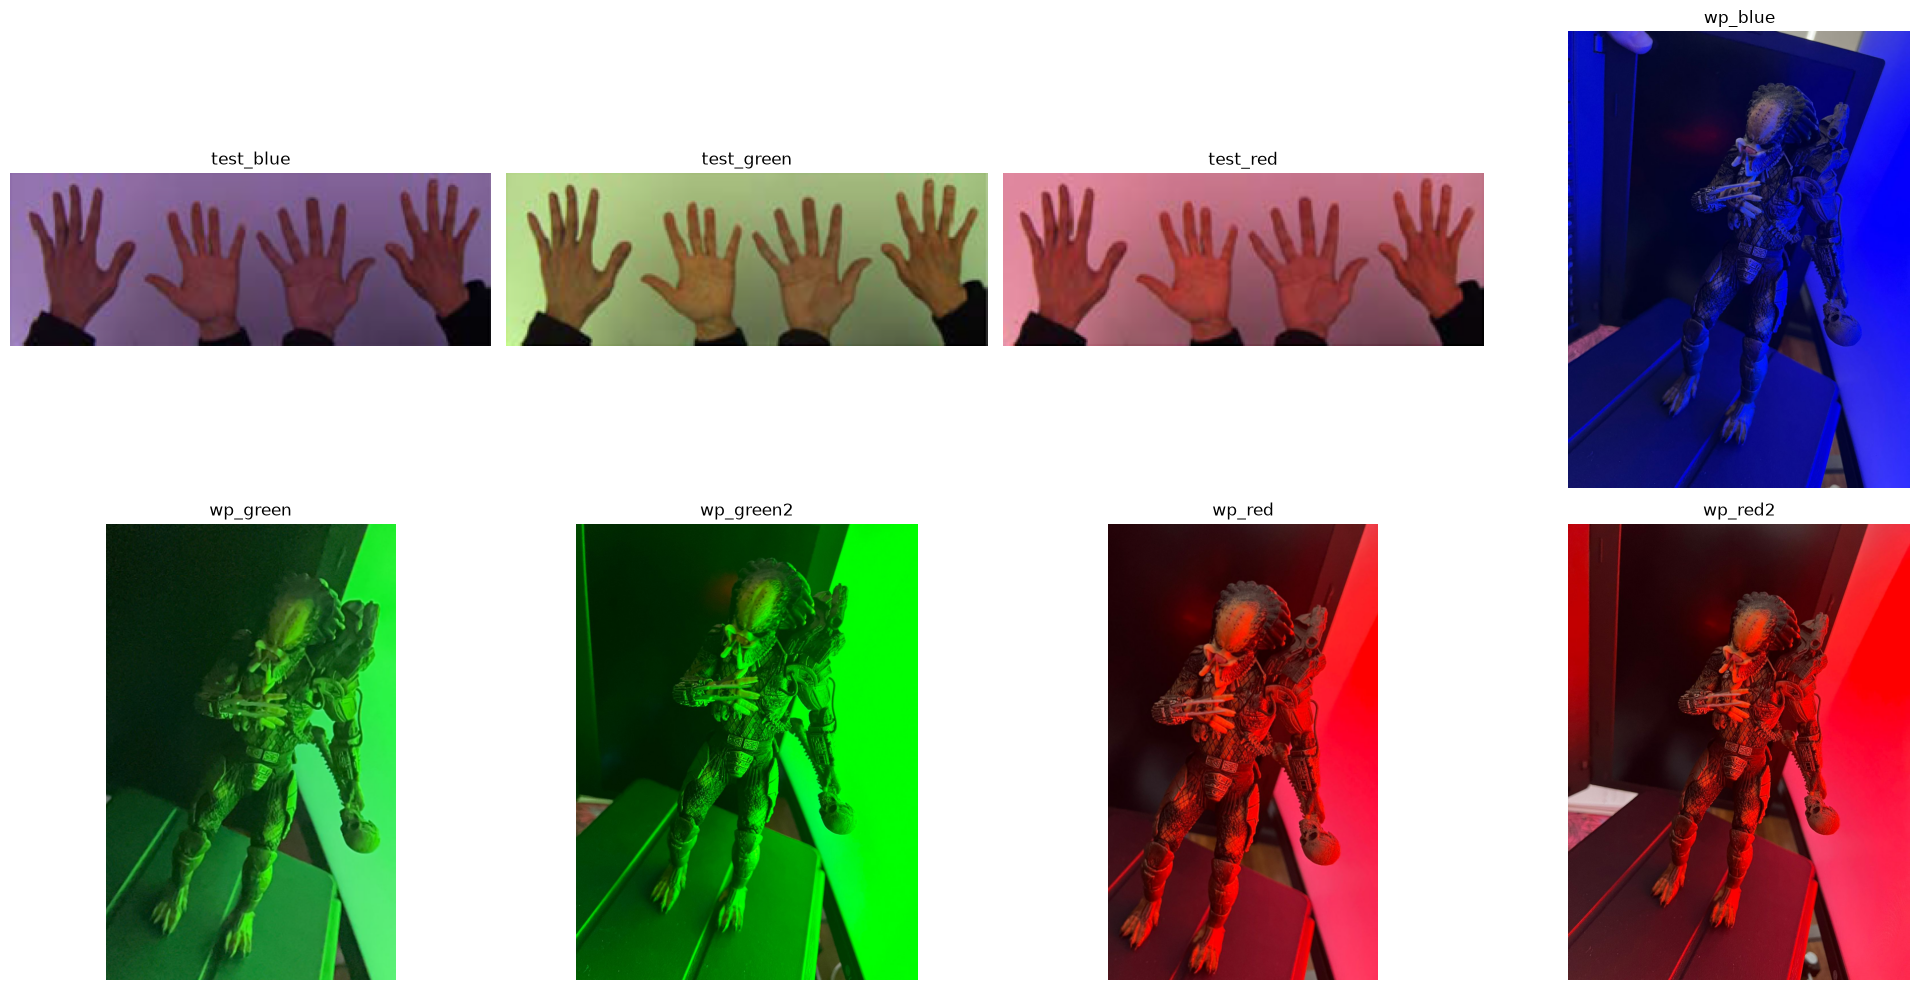

In [47]:
plot_image_grid(images, rows=2, cols=4)

## Implementación de algoritmo

El algoritmo de `white_patch` se define por generar un coeficiente con el que se escala el blanco, o píxel más brillante. El mismo es el cociente entre el máximo valor del dominio (255) y el máximo valor del canal. Esto se usa principalmente para filtrar la iluminación.Por lo tanto, un píxel blanco `(255,255,255)` debería Abajo se crea la función que recibe la imagen en rgb y aplica este cálculo. Devuelve una nueva imagen con los valores escalados

In [48]:
def white_patch(rgb_image):
    r_max = np.max(rgb_image[:, :, 0])
    g_max = np.max(rgb_image[:, :, 1])
    b_max = np.max(rgb_image[:, :, 2])

    new_img = rgb_image.copy()
    new_img[:, :, 0] = np.clip(rgb_image[:, :, 0] * (255.0 / r_max), 0, 255)
    new_img[:, :, 1] = np.clip(rgb_image[:, :, 1] * (255.0 / g_max), 0, 255)
    new_img[:, :, 2] = np.clip(rgb_image[:, :, 2] * (255.0 / b_max), 0, 255)
    return new_img

filtered = {}
for path, img in images.items():
    filtered[path] = [img, white_patch(img)]

Probando la primera imagen `test_blue` para ver la diferencia

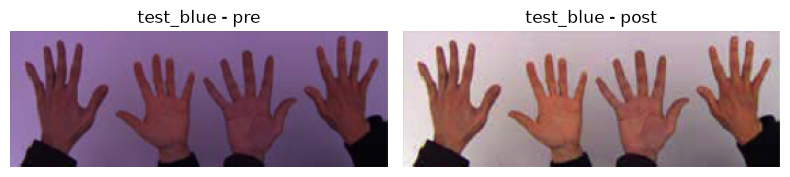

In [49]:
plot_diff_grid(filtered,keys=["test_blue"])

Aplicamos el diff a todas las imágenes

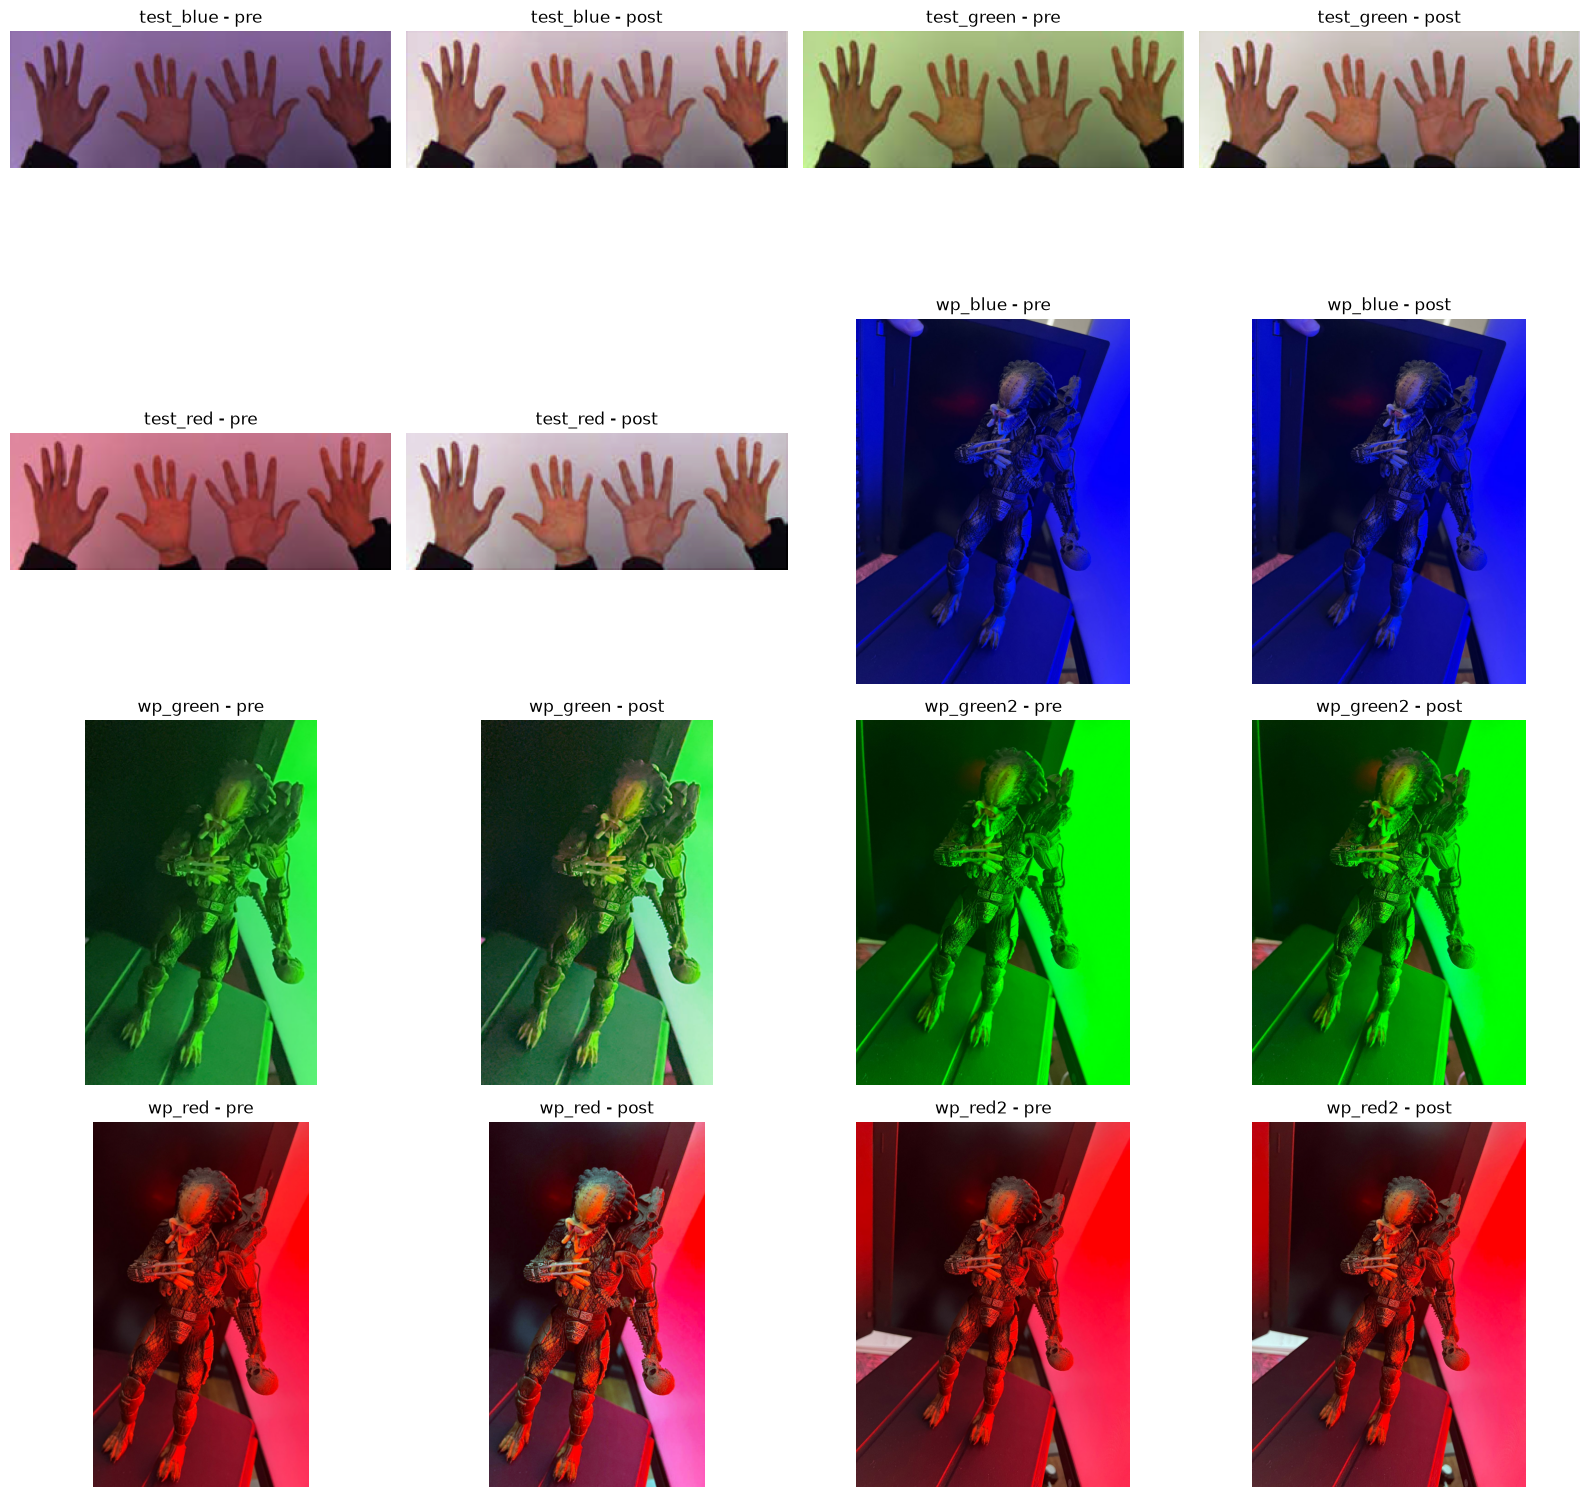

In [50]:
plot_diff_grid(filtered,pairs_per_row=2)

## Limitación del cálculo naive

El algoritmo `white_patch` implementado más arriba, calcula para cada canal, un factor `255 / max(canal)` de forma independiente. Esto asume implícitamente que existe un único punto de la escena que tiende a blanco, y que el máximo de cada canal coincide en ese mismo punto. En la práctica, el máximo de R, el de G y el de B pueden venir de tres píxeles completamente distintos, sin relación física entre sí.

Al aplicar el algoritmo sobre las 8 imágenes de `white_patch/`, se observa que en algunas casi no hay cambio visible. Para entender por qué, comparamos el canal verde de `wp_green` contra `wp_green2`. Observamos mediana, media y máximo:

In [80]:
comparison = [images["wp_green"][:,:,1], images["wp_green2"][:,:,1]]
for i in comparison:
    print(f"Mediana {np.median(i)} - Media {np.mean(i)} - Máximo {np.max(i)}")


Mediana 77.0 - Media 102.8459037115302 - Máximo 252
Mediana 94.0 - Media 126.10548697916667 - Máximo 255


El `max=255` en `wp_green2` confirma que el canal verde ya está saturado, por lo que su factor de corrección es `255/255 ≈ 1`. Es decir, el algoritmo no lo modifica, sin importar cómo esté distribuido el resto de la imagen.

## Mejora del algoritmo 

Para evitar mezclar máximos de píxeles distintos, `white_patch_v2` toma solamente el píxel más brillante según su luminancia perceptual (`cv.cvtColor(..., COLOR_RGB2GRAY)`, que pondera `0.299·R + 0.587·G + 0.114·B`). Se toma la tripleta `(R, G, B)` completa de ese píxel en lugar de tres máximos independientes y se calcula el factor de escala para cada canal a partir de ese único punto.

La aplicación del escalado se vectoriza con una matriz diagonal: `imagen @ diag(scale)`. Así se expresa como una única multiplicación matricial sobre todos los píxeles a la vez.

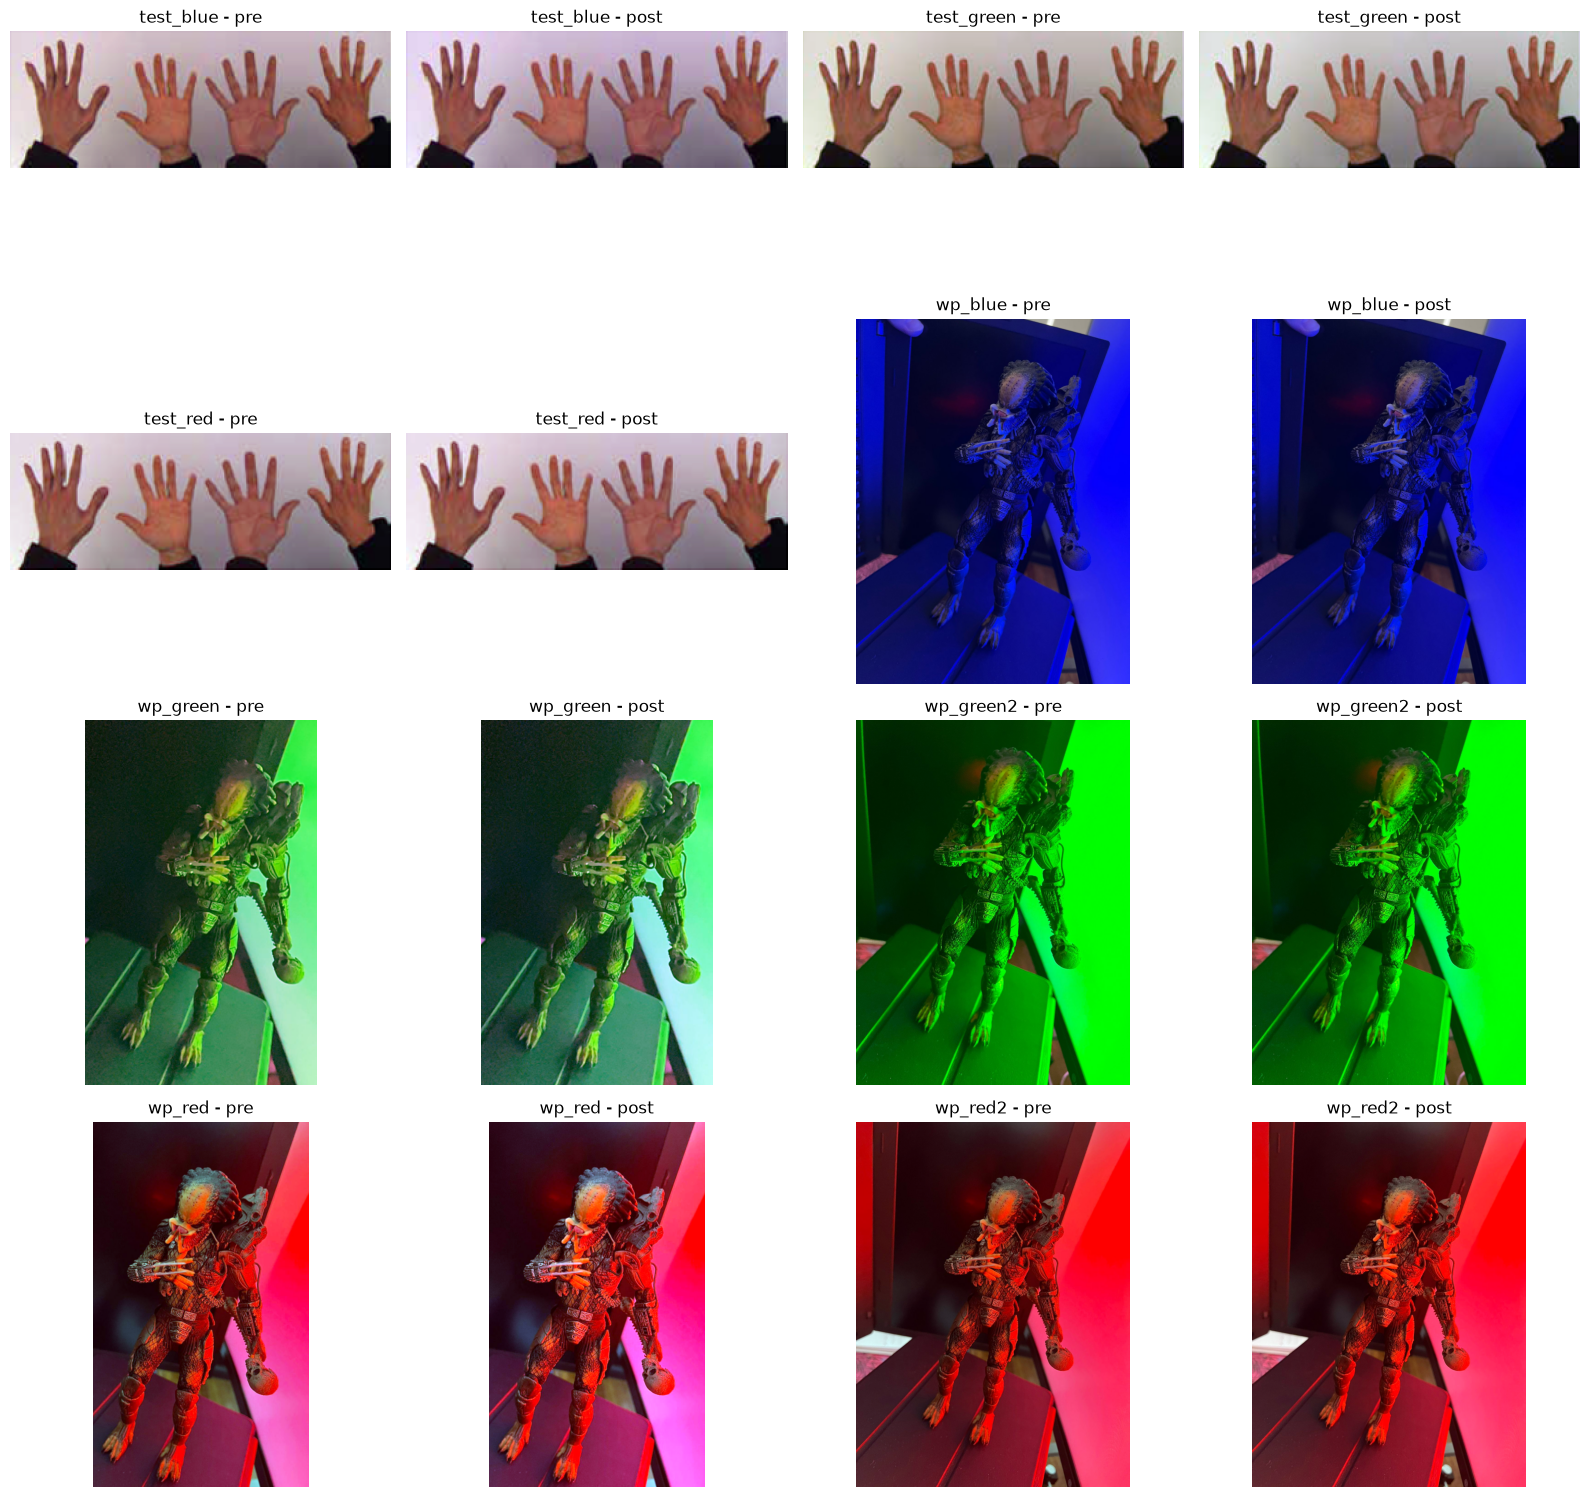

In [53]:
def white_patch_v2(rgb_image):
    scores = cv.cvtColor(rgb_image, cv.COLOR_RGB2GRAY)
    idx = np.unravel_index(np.argmax(scores), scores.shape)
    white_norm = rgb_image[idx].astype(np.float64)

    scale = 255.0 / np.clip(white_norm, 1, 255)
    new_img = rgb_image.astype(np.float64) @ np.diag(scale)
    return np.clip(new_img, 0, 255).astype(np.uint8)

filtered_v2 = {}
for path, img in images.items():
    filtered_v2[path] = [white_patch(img), white_patch_v2(img)]
plot_diff_grid(filtered_v2,pairs_per_row=2)

### Comparación cuantitativa entre métodos

Comparemos el nuevo algoritmo con su implementación anterior. Tomemos como medida el balance de la dispersión de las medias de los tres canales. Asumimos que la imagen queda más balanceada si las medias de los canales son parecidas entre sí. Dicho de otra forma, aplicamos la asunción de "gray-world"


In [81]:
def channel_mean_spread(img):
    """Dispersión (std) entre las medias de R, G y B.
    """
    means = [img[:, :, c].mean() for c in range(3)]
    return np.std(means)

print(f"{'imagen':12s} {'original':>10s} {'v1':>10s} {'v2':>10s}")
for path, img in images.items():
    v1 = white_patch(img)
    v2 = white_patch_v2(img)
    print(f"{path:12s} {channel_mean_spread(img):10.2f} {channel_mean_spread(v1):10.2f} {channel_mean_spread(v2):10.2f}")


imagen         original         v1         v2
test_blue         15.29      14.54      13.17
test_green        22.01      13.68      10.91
test_red          33.12      13.49      13.75
wp_blue           49.09      49.09      49.28
wp_green          34.29      23.08      22.32
wp_green2         57.48      56.61      56.61
wp_red            47.60      37.90      42.53
wp_red2           48.77      45.94      50.17


## Limitación de fondo

Al comparar `white_patch` (v1) contra `white_patch_v2` sobre las 8 imágenes, las `test_` mejoran, excepto por una leve alteración en ``test_red`; pero las `wp_` siguen prácticamente igual o empeoran. El fondo, por ejemplo verde en `wp_green2` satura tanto la escena que incluso el píxel de mayor luminancia tiene G $≈$ 255. No existe, dentro de esta imagen, ningún píxel que sea realmente blanco o gris neutro.

En conclusión white-patch depende de que exista, físicamente, un punto de referencia cercano al blanco en la escena. Cuando la iluminación de la escena satura un canal de color , ninguna variante del algoritmo puede corregir el balance



## Generalización de patching con `color_patch`

Como una curiosidad, me basé en el principio del white-patch y me pregunté qué pasaría si yo balanceara toda la imagen con un color específico como base. Para eso, reemplacé el objetivo fijo `(255,255,255)` por un color dado. Con este algoritmo, se puede filtrar con un color arbitrario a la imagen

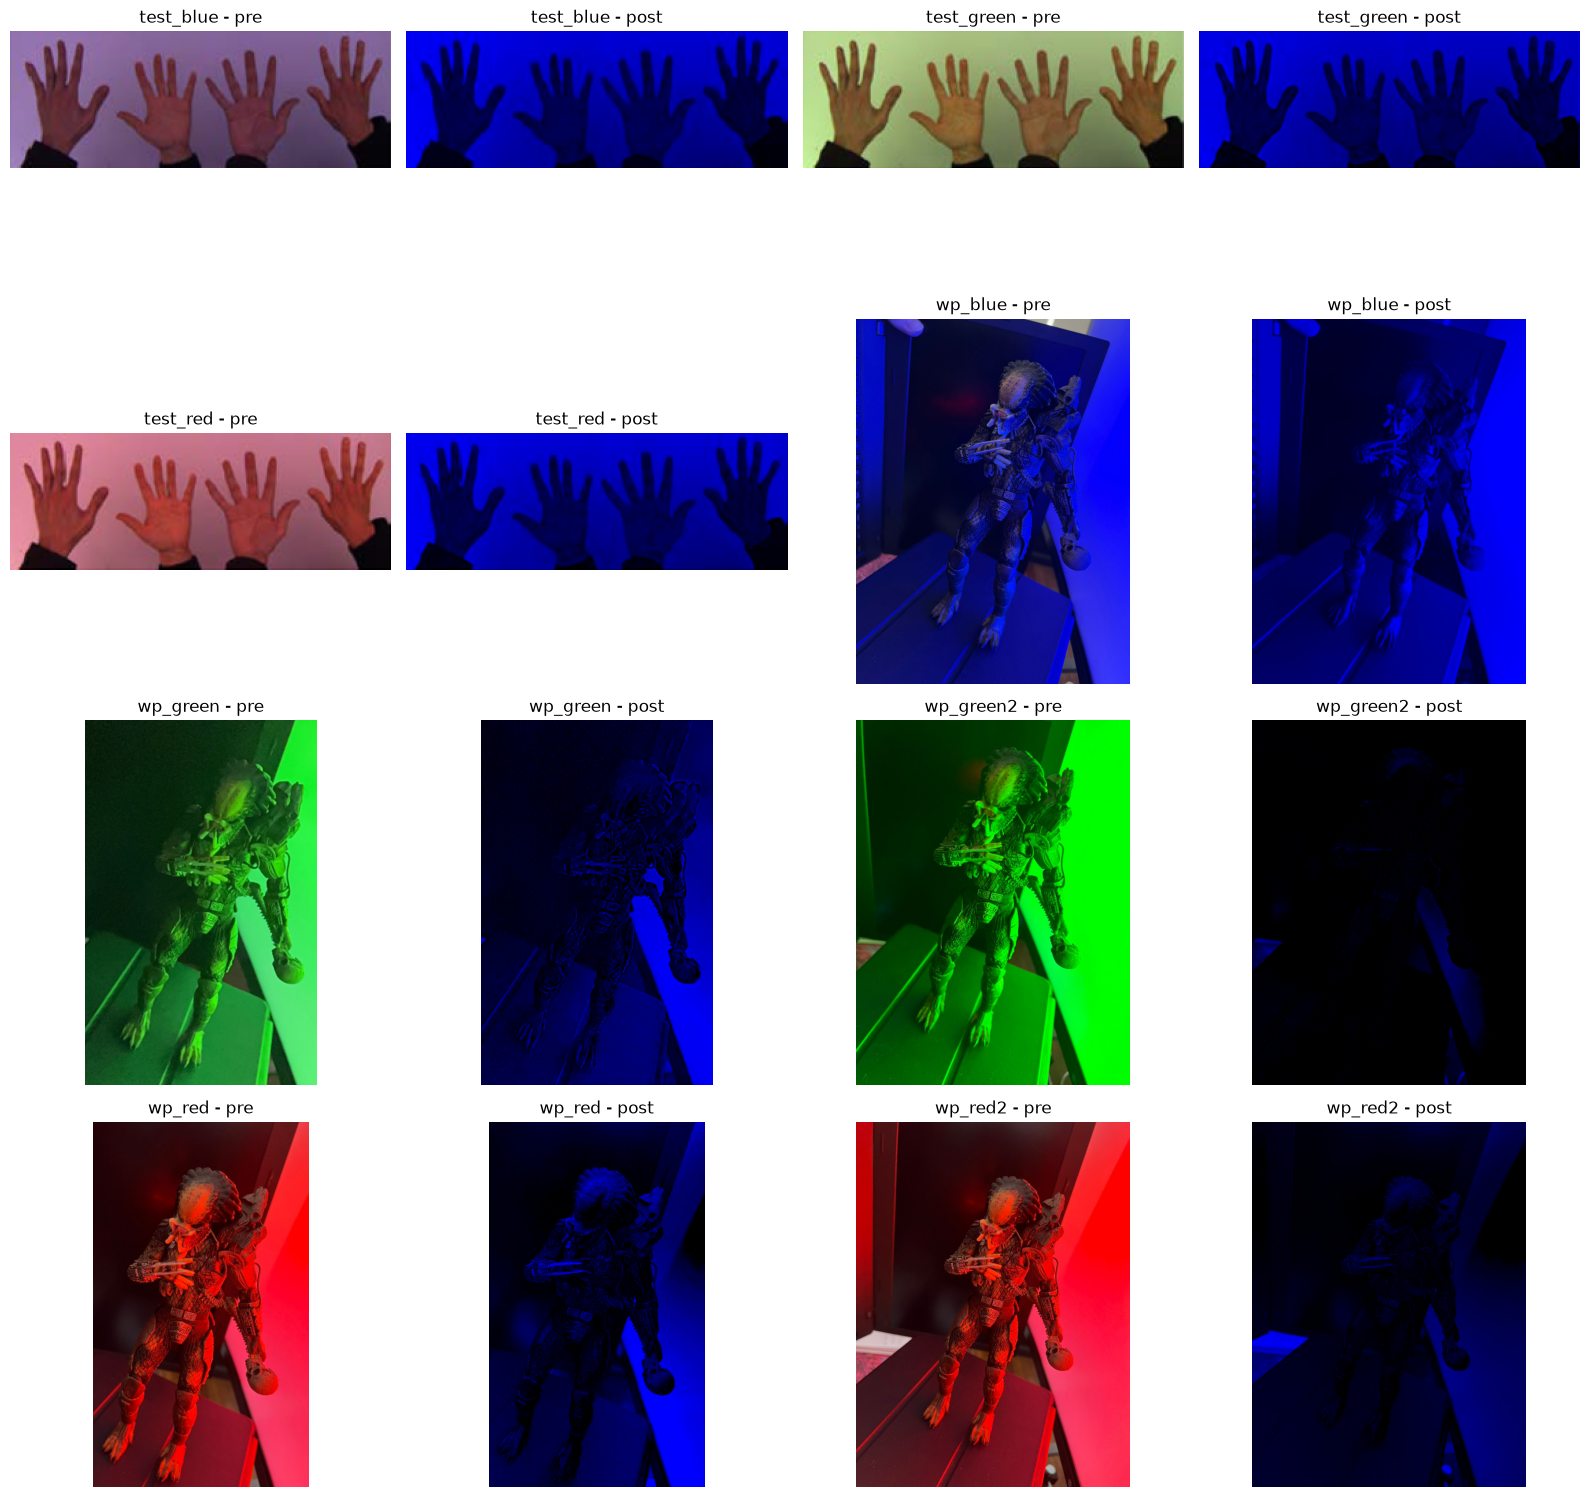

In [55]:
def color_patch(rgb_image, target_rgb=(255, 255, 255)):
    scores = cv.cvtColor(rgb_image, cv.COLOR_RGB2GRAY)
    idx = np.unravel_index(np.argmax(scores), scores.shape)
    reference_pixel = rgb_image[idx].astype(np.float64)

    target = np.array(target_rgb, dtype=np.float64)
    scale = target / np.clip(reference_pixel, 1, 255)

    new_img = rgb_image.astype(np.float64) @ np.diag(scale)
    return np.clip(new_img, 0, 255).astype(np.uint8)

basic_colors = {
    "white": (255, 255, 255),
    "red": (255, 0, 0),
    "green": (0, 255, 0),
    "blue": (0, 0, 255),
    "yellow": (255, 255, 0),
    "cyan": (0, 255, 255),
    "magenta": (255, 0, 255),
    "orange": (255, 165, 0),
    "purple": (128, 0, 128),
}
color_filtered = {}
for path, img in images.items():
    color_filtered[path] = [img, color_patch(img,basic_colors["blue"])]
plot_diff_grid(color_filtered,pairs_per_row=2)

---

# Parte 2:
1. Para las imágenes img1_tp.png y img2_tp.png leerlas con OpenCV en escala de grisas y 
visualizarlas. 
2. Elija el numero de bins que crea conveniente y grafique su histograma, compare los histogramas 
entre si. Explicar lo que se observa, si tuviera que entrenar un modelo de clasificación/detección 
de imágenes, considera que puede ser de utilidad tomar como ‘features’ a los histogramas?

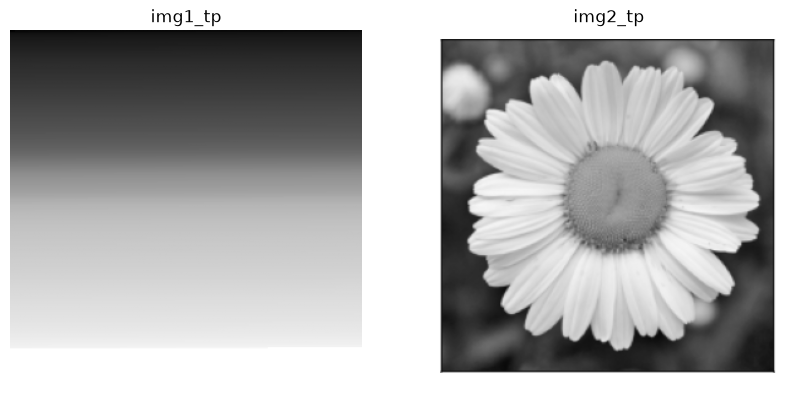

In [56]:
img1_gray = cv.imread('img1_tp.png', cv.IMREAD_GRAYSCALE)
img2_gray = cv.imread('img2_tp.png', cv.IMREAD_GRAYSCALE)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(img1_gray, cmap='gray')
axs[0].set_title('img1_tp')
axs[0].axis('off')
axs[1].imshow(img2_gray, cmap='gray')
axs[1].set_title('img2_tp')
axs[1].axis('off')
plt.show()

Voy a aplicar dos enfoques para el histograma. El primero será que tenga tantos bins como valores posibles (256). El segundo será recortar la cantidad de bins según el rango intercuartílico de los valores. En lugar de hacer el cálculo del IQR simple, voy a usar el cálculo de Freedman-Diaconis que es un algoritmo para calcular los bins óptimos en un histograma. `matplotlib.pyplot` ya tiene una implementación del mismo via `hist(bins="fd")`

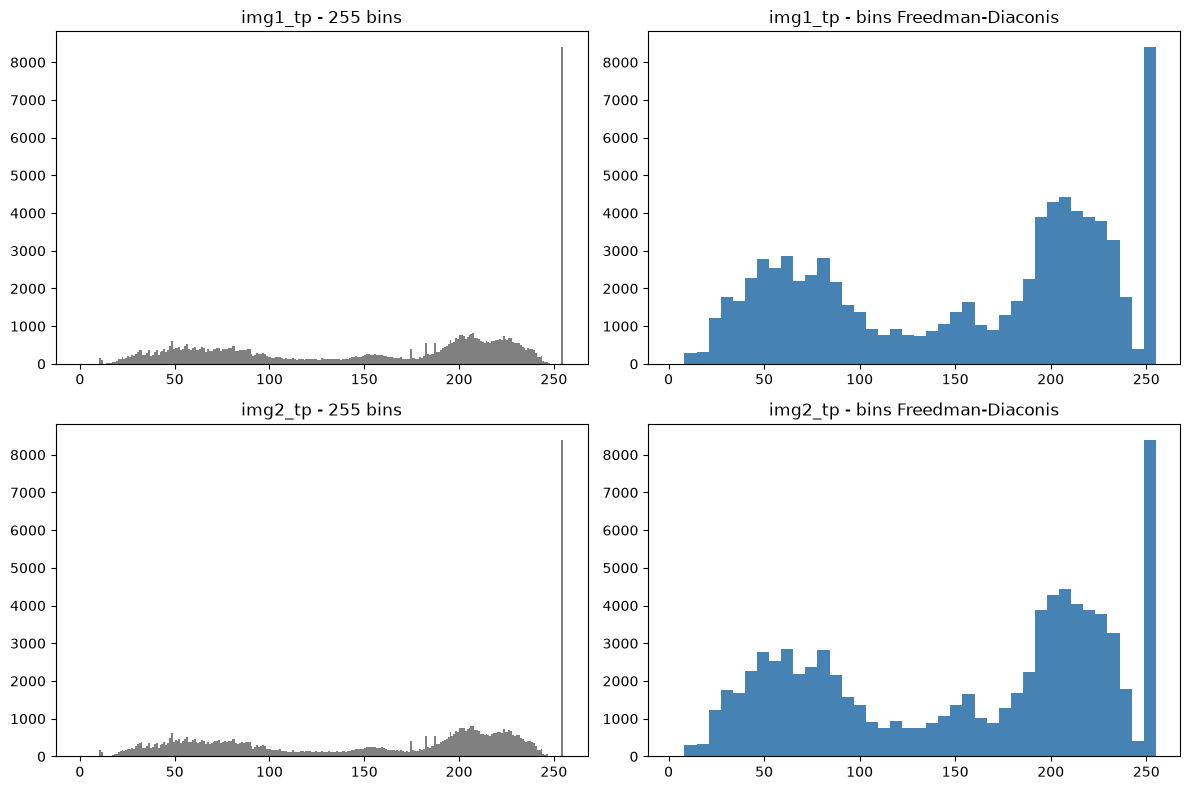

In [60]:
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

for row, (name, gray) in enumerate([("img1_tp", img1_gray), ("img2_tp", img2_gray)]):
    axs[row, 0].hist(gray.ravel(), bins=255, range=(0, 255), color='gray')
    axs[row, 0].set_title(f"{name} - 255 bins")

    axs[row, 1].hist(gray.ravel(), bins='fd', color='steelblue')
    axs[row, 1].set_title(f"{name} - bins Freedman-Diaconis")

plt.tight_layout()
plt.show()

Los histogramas muestran una clara diferencia entre métodos. Sin embargo, entre imágenes son exactamente iguales. Es decir, las dos imágenes tienen el mismo conjunto y frecuencia relativa de valores

In [78]:
img_1_vals = np.sort(img1_gray.ravel())
img_2_vals = np.sort(img2_gray.ravel())
print("Misma frecuencia relativa:",  np.array_equal(img_1_vals, img_2_vals))
print(f"¿Cuántos coinciden espacialmente? {((img1_gray == img2_gray).sum()/ img1_gray.size)*100:.2}%") 


Misma frecuencia relativa: True
¿Cuántos coinciden espacialmente? 3.8%


A nivel numérico, las dos imágenes tienen el mismo conjunto de valores; son una combinación lineal una de la otra o, en su defecto, son los mismos valores reordenados. Queda claro que el histograma no nos da información ni espacial ni de figuras de la imagen. Lo que sí nos da es información sobre los valores de luminosidad o color. Si una imagen estuviera muy intensa de luz podríamos distinguirla de otra más oscura. Un histograma como feature sería útil si la tarea de clasificación consiste en diferenciar la distribución de densidades. No sería algo útil si necesitáramos analizar formas o contraste